In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_maxpooling import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
#CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 29837
Antal med m-komponent i träningsdatan: 2553


In [2]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
Epoch   0 | train: 11.1476 | val: 1.1291 | acc: 12.82% | AUC: 0.536  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_avg_and_max_pool_fold1.pth
Epoch   1 | train: 0.8347 | val: 0.6362 | acc: 56.15% | AUC: 0.692  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_avg_and_max_pool_fold1.pth
Epoch   2 | train: 0.5716 | val: 0.7185 | acc: 90.39% | AUC: 0.765  | LR: 0.001
Epoch   3 | train: 0.4929 | val: 0.4613 | acc: 88.53% | AUC: 0.841  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_avg_and_max_pool_fold1.pth
Epoch   4 | train: 0.4520 | val: 0.4572 | acc: 81.75% | AUC: 0.846  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_avg_and_max_pool_fold1.pth
Epoch   5 | train: 0.4428 | val: 0.4523 | acc: 90.34% | AUC: 0.854  | LR: 0.001
  -> ny bä

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.153586,0.209350,94.008360,0.975872
1,2,0.077720,0.117465,95.171773,0.988673
2,3,0.143159,0.224980,93.361188,0.962891
3,4,0.121863,0.186313,95.541105,0.977766
4,5,0.095755,0.162151,94.284387,0.985735
5,6,0.071294,0.145208,95.773340,0.985353
6,7,0.093897,0.149191,95.539033,0.981028
7,8,0.107169,0.207034,92.896936,0.973603
8,9,0.090743,0.195844,95.306691,0.978317
9,10,0.084105,0.138431,95.821727,0.985564


              precision    recall  f1-score   support

     Negativ       0.99      0.98      0.99      7146
     Positiv       0.82      0.91      0.86       586

    accuracy                           0.98      7732
   macro avg       0.91      0.95      0.93      7732
weighted avg       0.98      0.98      0.98      7732

[[7027  119]
 [  51  535]]
AUC: 0.9865496724103512
Accuracy:  97.80%
FN-rate:   8.70%  (farliga missade fall)
FP-rate:   1.67%  (onödiga larm)
Sensitivitet:   91.30%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.33%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9865


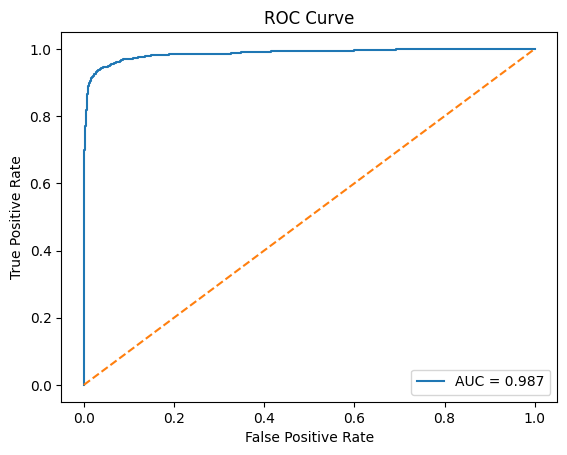

In [2]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)